Looking in indexes: http://mirrors.aliyun.com/pypi/simple/
     ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.6 MB 108.9 kB/s eta 0:01:28
     ---------------------------------------- 0.0/9.6 MB 119.1 kB/s eta 0:01:21
     ---------------------------------------- 0.0/9.6 MB 119.1 kB/s eta 0:01:21
     ---------------------------------------- 0.0/9.6 MB 119.1 kB/s eta 0:01:21
     ---------------------------------------- 0.0/9.6 MB 109.3 kB/s eta 0:01:28
     ---------------------------------------- 0.0/9.6 MB 109.3 kB/s eta 0:01:28
     ---------------------------------------- 0.1/9.6 MB 109.2 kB/s eta 0:01:28
     ---------------------

In [1]:
import requests
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.edge.service import Service
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
import time
import pandas as pd
from selenium.common.exceptions import NoSuchElementException

# 使用 requests.Session() 进行登录
session = requests.Session()

# 登录页面的URL和表单数据
login_url = "https://id.sspu.edu.cn/"
login_data = {
    "username": "20211110115",
    "password": "Www.20031002"
}
# 提交登录请求
session.post(login_url, data=login_data)

# 设置Edge驱动器的路径
edge_driver_path = 'E:\\EdgeDriver\\edgedriver_win64\\msedgedriver.exe'

# 启动 Selenium，并设置使用Edge浏览器
driver = webdriver.Edge(service=Service(edge_driver_path))

# 访问登录页面以确保能够添加 cookies
driver.get("https://id.sspu.edu.cn/")

# 将 requests.Session() 中的 cookies 导入到 Selenium
for cookie in session.cookies:
    driver.add_cookie({
        'name': cookie.name,
        'value': cookie.value,
        'domain': cookie.domain,
        'path': cookie.path
    })

# 手动完成登录过程
username_input = driver.find_element(By.CSS_SELECTOR, 'input.el-input__inner[type="text"]')
username_input.send_keys(login_data['username'])

password_input = driver.find_element(By.CSS_SELECTOR, 'input.el-input__inner[type="password"]')
password_input.send_keys(login_data['password'])

login_button = driver.find_element(By.CSS_SELECTOR, 'button.el-button.login-btn')
login_button.click()

# 确保登录后网页已经加载，可以添加一个等待时间
time.sleep(2)  # 根据实际情况调整时间
driver.get("https://oa.sspu.edu.cn/wui/index.html")

time.sleep(2)  
# 跳转到其他网页
driver.get("https://oa.sspu.edu.cn/interface/Entrance.jsp?id=bzkjw")

time.sleep(2)
driver.get("https://oa.sspu.edu.cn/interface/Entrance.jsp?id=bzkjw")


time.sleep(2)
driver.get("https://jx.sspu.edu.cn/eams/home!index.action")

time.sleep(2)
driver.get("https://jx.sspu.edu.cn/eams/scheduleSearch.action")

# 等待页面加载完成
time.sleep(2)




# 1. 使用 title="学年学期" 来找到学年学期输入框
semester_input = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.XPATH, "//input[@title='学年学期']"))
)
semester_input.click()

# 2. 等待学年表格可见并选择学年
year_table = WebDriverWait(driver, 10).until(
    EC.visibility_of_element_located((By.ID, "semesterCalendar_yearTb"))
)
target_year = WebDriverWait(year_table, 10).until(
    EC.element_to_be_clickable((By.XPATH, "//td[text()='2023-2024']"))
)
target_year.click()

# 3. 等待学期表格可见并选择学期
term_table = WebDriverWait(driver, 10).until(
    EC.visibility_of_element_located((By.ID, "semesterCalendar_termTb"))
)
target_term = WebDriverWait(term_table, 10).until(
    EC.element_to_be_clickable((By.XPATH, "//td[@val='902']"))  # 选择秋季学期
)
target_term.click()

# 4. 提交表单切换学期
submit_button = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.XPATH, "//input[@type='submit' and @value='切换学期']"))
)
submit_button.click()

# 等待页面加载新的数据
time.sleep(5)




# 继续获取和处理页面数据
page_source = driver.page_source
soup = BeautifulSoup(page_source, 'html.parser')


# 获取并处理页面数据
all_courses = []

while True:
    # 获取当前页面的源代码并解析
    page_source = driver.page_source
    soup = BeautifulSoup(page_source, 'html.parser')

    # 查找课程数据表格
    course_rows = []
    indexpanel = soup.find('table', class_='indexpanel')
    if indexpanel:
        td_element = soup.find('td', class_='index_content')
        if td_element:
            content_div = td_element.find('div', id='contentDiv', class_='_ajax_target')
            if content_div:
                grid_div = content_div.find('div', class_='grid')
                if grid_div:
                    table = grid_div.find('table', class_='gridtable')
                    if table:
                        tbody = table.find('tbody')
                        course_rows = tbody.find_all('tr') if tbody else table.find_all('tr')
                    else:
                        print("Table not found within gridbar div.")
                else:
                    print("Grid div not found.")
            else:
                print("Content div not found.")
        else:
            print("Index content td not found.")
    else:
        print("indexpanel td not found.")

    # 解析并保存每行课程数据
    for row in course_rows:
        cells = row.find_all('td')
        if len(cells) > 13:  # 确保单元格数足够
            schedule_cell = cells[5]  # 排课安排的单元格
            schedules = schedule_cell.get_text(separator='|').split('|')  # 使用'|'作为分隔符来分割每个排课安排
            schedule_details = [schedule.strip() for schedule in schedules if schedule.strip()]  # 清理空格
            course_info = {
                "序号": cells[1].text.strip(),
                "课程代码": cells[2].text.strip(),
                "课程名称": cells[3].find('a').text.strip() if cells[3].find('a') else cells[3].text.strip(),
                "教师": cells[4].text.strip(),
                "排课安排": schedule_details,  # 保存排课安排列表
                "课程类别": cells[6].text.strip(),
                "教学班": cells[7].text.strip(),
                "实际人数": cells[8].text.strip(),
                "上限": cells[9].text.strip(),
                "课时": cells[10].text.strip(),
                "学分": cells[11].text.strip(),
                "起始周": cells[12].text.strip(),
                "周数": cells[13].text.strip()
            }
            all_courses.append(course_info)

    # 查找下一页按钮并点击，如果不可点击则退出循环
    try:
        next_page = driver.find_element(By.LINK_TEXT, '后页 ›')
        if 'disabled' in next_page.get_attribute('class'):
            break
        next_page.click()
        time.sleep(2)  # 等待页面加载
    except:
        break

# 将数据存储到 DataFrame 中
df_courses = pd.DataFrame(all_courses)

df_courses.to_excel('2024courses_schedule.xlsx',index=False, sheet_name='课程表')

# 关闭浏览器
driver.quit()

NoSuchWindowException: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: MicrosoftEdge=128.0.2739.67)
Stacktrace:
	GetHandleVerifier [0x00007FF742763A52+10594]
	Microsoft::Applications::Events::ILogConfiguration::operator* [0x00007FF742700479+323337]
	(No symbol) [0x00007FF74251F16E]
	(No symbol) [0x00007FF7424FAB19]
	(No symbol) [0x00007FF74258E7CB]
	(No symbol) [0x00007FF7425A145A]
	(No symbol) [0x00007FF7425877E3]
	(No symbol) [0x00007FF74255B3EC]
	(No symbol) [0x00007FF74255A8CD]
	(No symbol) [0x00007FF74255AFB1]
	Microsoft::Applications::Events::EventProperty::empty [0x00007FF7428EE4F4+918756]
	Microsoft::Applications::Events::EventProperty::~EventProperty [0x00007FF74268C9BF+54575]
	Microsoft::Applications::Events::EventProperty::~EventProperty [0x00007FF74267F557+199]
	Microsoft::Applications::Events::EventProperty::empty [0x00007FF7428ED27D+914029]
	Microsoft::Applications::Events::ILogConfiguration::operator* [0x00007

In [5]:
import pandas as pd

# 读取 Excel 文件
file_path = '2024courses_schedule.xlsx'  # 请确保使用正确的文件路径
df = pd.read_excel(file_path)

# 删除课程名称为“研究生系统接口占用课程”的行
df_filtered = df[df['课程名称'] != '研究生系统接口占用课程']

# 将过滤后的数据保存回 Excel 文件
filtered_file_path = 'filtered_2024courses_schedule.xlsx'
df_filtered.to_excel(filtered_file_path, index=False)

print("研究生课程已删除，结果已保存至 filtered_2024courses_schedule.xlsx")

研究生课程已删除，结果已保存至 filtered_2024courses_schedule.xlsx


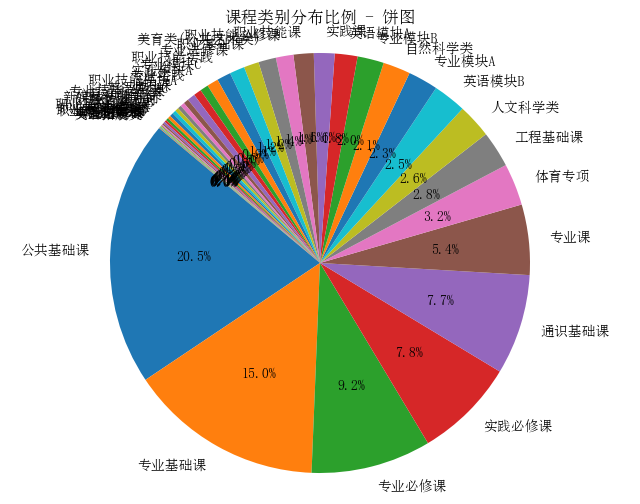

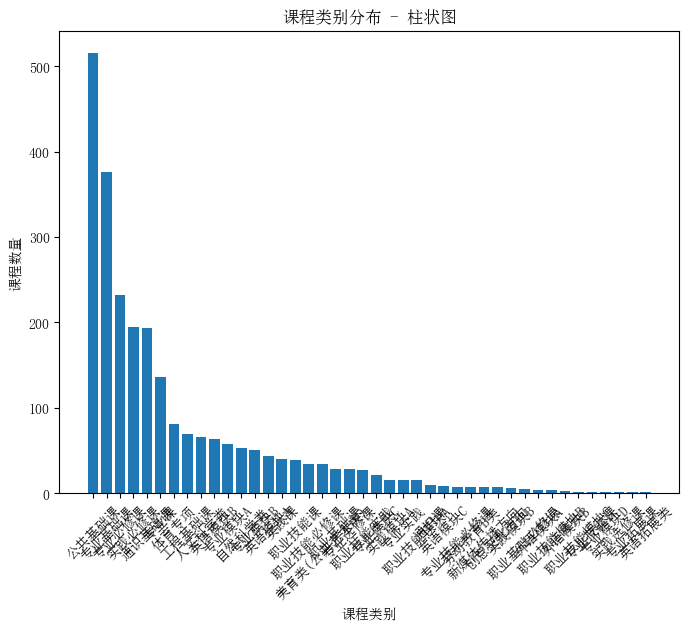

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font = FontProperties(fname='C:\Windows\Fonts\simhei.ttf') 
plt.rcParams['font.sans-serif'] = ['SimSun']

# 读取 Excel 文件
file_path = '2024cs.xlsx'  # 请确保使用正确的文件路径
df = pd.read_excel(file_path)

# 统计每种课程类别的数量
category_counts = df['课程类别'].value_counts()

# 绘制饼图
plt.figure(figsize=(8, 6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('课程类别分布比例 - 饼图')
plt.axis('equal')  # 确保饼图是圆形的
plt.show()

# 绘制柱状图
plt.figure(figsize=(8, 6))
plt.bar(category_counts.index, category_counts.values)
plt.title('课程类别分布 - 柱状图')
plt.xlabel('课程类别')
plt.ylabel('课程数量')
plt.xticks(rotation=45)
plt.show()

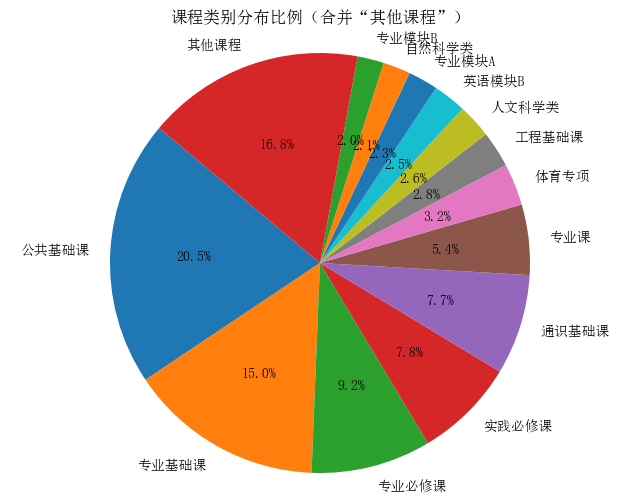

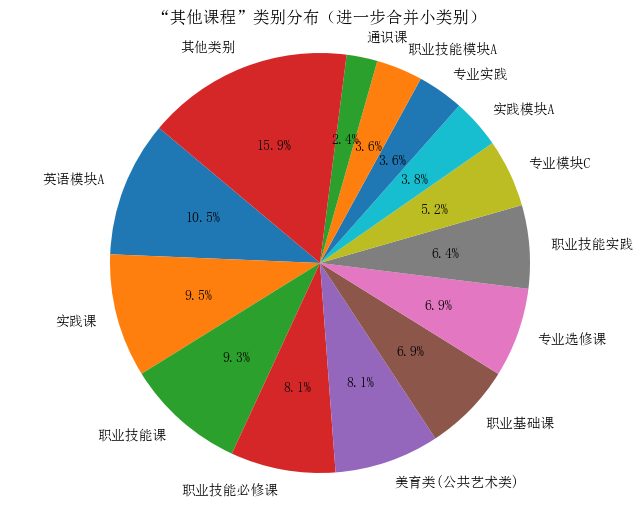

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
file_path = '2024cs.xlsx'  # 请确保使用正确的文件路径
df = pd.read_excel(file_path)

# 统计每种课程类别的数量
category_counts = df['课程类别'].value_counts()
total_courses = category_counts.sum()

# 计算每个类别的占比，并将比例小于2%的归类为“其他课程”
category_percent = (category_counts / total_courses) * 100
main_categories = category_percent[category_percent >= 2.0]
other_categories = category_percent[category_percent < 2.0]

# 合并“其他课程”的数量
other_total = other_categories.sum()
category_combined = main_categories.copy()
category_combined['其他课程'] = other_total

# 绘制总的饼图
plt.figure(figsize=(8, 6))
plt.pie(category_combined, labels=category_combined.index, autopct='%1.1f%%', startangle=140)
plt.title('课程类别分布比例（合并“其他课程”）')
plt.axis('equal')  # 确保饼图是圆形的
plt.show()

# 在“其他课程”内部进一步归类，将小于2%的归为“其他类别”
if len(other_categories) > 0:
    other_percent = (other_categories / other_total) * 100
    major_other_categories = other_percent[other_percent >= 2.0]
    minor_other_categories = other_percent[other_percent < 2.0]

    # 合并“其他课程”中小于2%的类别为“其他类别”
    if minor_other_categories.sum() > 0:
        major_other_categories['其他类别'] = minor_other_categories.sum()

    # 绘制“其他课程”的细分饼图
    plt.figure(figsize=(8, 6))
    plt.pie(major_other_categories, labels=major_other_categories.index, autopct='%1.1f%%', startangle=140)
    plt.title('“其他课程”类别分布（进一步合并小类别）')
    plt.axis('equal')
    plt.show()
else:
    print("没有比例小于 2% 的课程类别。")

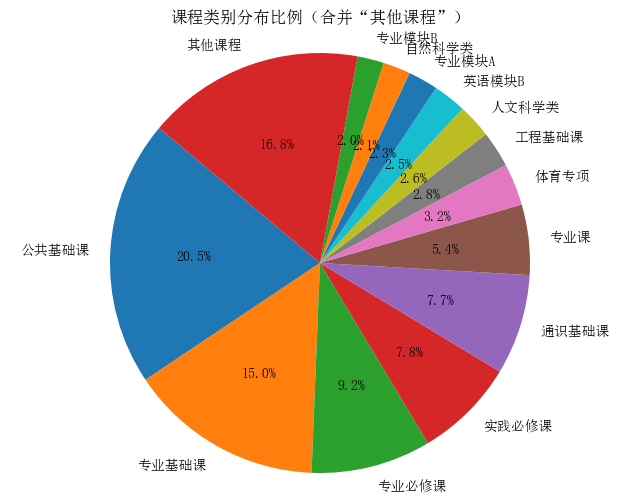

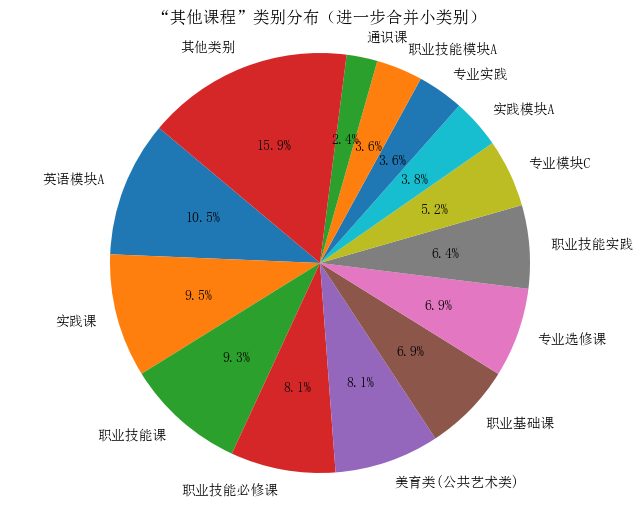

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
file_path = '2024cs.xlsx'  # 请确保使用正确的文件路径
df = pd.read_excel(file_path)

# 统计每种课程类别的数量
category_counts = df['课程类别'].value_counts()
total_courses = category_counts.sum()

# 计算每个类别的占比，并将比例小于2%的归类为“其他课程”
category_percent = (category_counts / total_courses) * 100
main_categories = category_percent[category_percent >= 2.0]
other_categories = category_percent[category_percent < 2.0]

# 合并“其他课程”的数量
other_total = other_categories.sum()
category_combined = main_categories.copy()
category_combined['其他课程'] = other_total

# 绘制总的饼图
plt.figure(figsize=(8, 6))
plt.pie(category_combined, labels=category_combined.index, autopct='%1.1f%%', startangle=140)
plt.title('课程类别分布比例（合并“其他课程”）')
plt.axis('equal')  # 确保饼图是圆形的
plt.show()

# 在“其他课程”内部进一步归类，将小于2%的归为“其他类别”
if len(other_categories) > 0:
    # 计算“其他课程”内部的百分比
    other_percent = (other_categories / other_total) * 100
    major_other_categories = other_percent[other_percent >= 2.0]
    minor_other_categories = other_percent[other_percent < 2.0]

    # 合并“其他课程”中小于2%的类别为“其他类别”
    if minor_other_categories.sum() > 0:
        major_other_categories['其他类别'] = minor_other_categories.sum()

    # 绘制“其他课程”的细分饼图
    plt.figure(figsize=(8, 6))
    plt.pie(major_other_categories, labels=major_other_categories.index, autopct='%1.1f%%', startangle=140)
    plt.title('“其他课程”类别分布（进一步合并小类别）')
    plt.axis('equal')
    plt.show()
else:
    print("没有比例小于 2% 的课程类别。")

In [11]:
import pandas as pd

# 读取 Excel 文件
file_path = '2024cs.xlsx'  # 输入原始文件路径
df = pd.read_excel(file_path)

# 定义计信学院专业列表
cs_department_majors = [

        '计算机科学与技术', '网络工程', '软件工程', '数字媒体技术',
        '智能科学与技术', '数据科学与大数据技术', '电子信息工程', '通信工程'

]

# 筛选出属于计信学院的专业数据
filtered_df = df[df['教学班'].isin(cs_department_majors)]

# 保存筛选后的数据到新的 Excel 文件
output_file_path = '计信学院上课信息表.xlsx'  # 输出文件路径
filtered_df.to_excel(output_file_path, index=False)

print(f"数据已保存到 {output_file_path}")

数据已保存到 计信学院上课信息表.xlsx


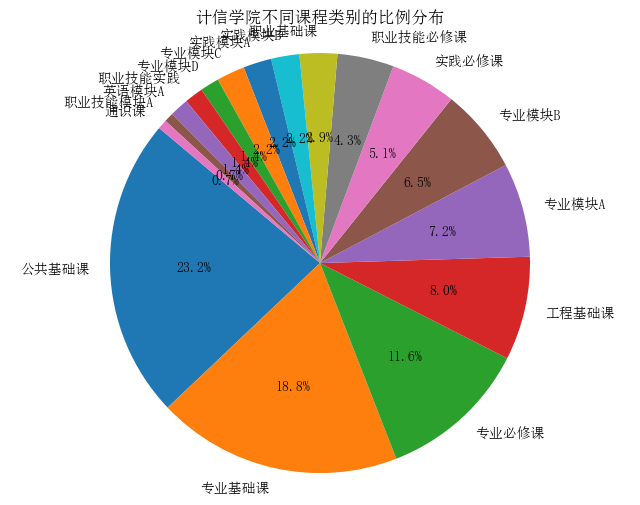

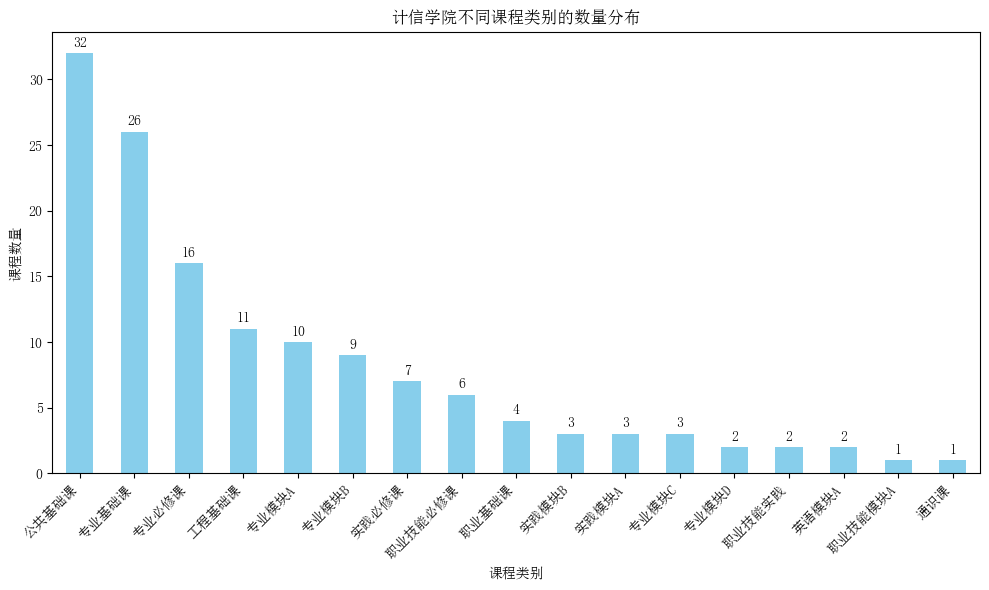

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取计信学院上课信息表
file_path = '计信学院上课信息表.xlsx'  # 请确保文件路径正确
df = pd.read_excel(file_path)

# 统计每种课程类别的数量
category_counts = df['课程类别'].value_counts()

# 计算每个课程类别的比例
category_percent = (category_counts / category_counts.sum()) * 100

# 绘制饼图展示课程类别比例
plt.figure(figsize=(8, 6))
plt.pie(category_percent, labels=category_percent.index, autopct='%1.1f%%', startangle=140)
plt.title('计信学院不同课程类别的比例分布')
plt.axis('equal')  # 确保饼图是圆形的
plt.show()

# 绘制柱状图展示课程类别数量分布
plt.figure(figsize=(10, 6))
bars = category_counts.plot(kind='bar', color='skyblue')
plt.title('计信学院不同课程类别的数量分布')
plt.xlabel('课程类别')
plt.ylabel('课程数量')
plt.xticks(rotation=45, ha='right')  # 旋转x轴标签，防止重叠

# 在柱状图的柱子上标注数量
for index, value in enumerate(category_counts):
    plt.text(index, value + 0.5, str(value), ha='center')

plt.tight_layout()  # 调整布局以防止标签重叠
plt.show()